In [2]:
import numpy as np
import matplotlib.pyplot as plt
from testrig_control_with_sofirpy.experimental_run import ExperimentalRun

# from sofirpy import plot_results
import test_rig_control_model.common as co
from testrig_control_with_sofirpy.utils import get_run_names_from_file

plt.style.use("FST.mplstyle")
plt.rcParams["font.size"] = 10
plt.rcParams.update({"text.usetex": True, "font.family": "Helvetica"})

In [3]:
k1 = -770690.9261910986
k2 = 7.624228003861329
k3 = 0.0020417184101237

s_1 = 35.36
s_2 = 41.6667
s_max = 74.16666667

q_list = np.linspace(0.00009, 0.00014, 1000)

pump_curve_1 = np.array(
    [k1 * q**2 + k2 * q * s_1 + 1.01930 * k3 * s_1**2 for q in q_list]
)
pump_curve_2 = np.array(
    [k1 * q**2 + k2 * q * s_2 + 0.827 * k3 * s_2**2 for q in q_list]
)

In [4]:
def get_exp_results(file_name, run_index):
    run_names = get_run_names_from_file(co.DATA_DIR / file_name)
    usable_runs = run_names
    run = ExperimentalRun.from_hdf5(usable_runs[run_index], co.DATA_DIR / file_name)
    return run.time_series


exp_df_c_35_75 = get_exp_results("system_1_constant_operating_point_3536_75.hdf5", 1)
exp_df_c_35_50 = get_exp_results(
    "subsystem_1_step_response_operating_point_2kPa.hdf5", 11
)
exp_df_c_41_75 = get_exp_results("system_1_constant_operating_point_4167_75.hdf5", 0)
exp_df_p_35_41 = get_exp_results("system_1_pump_speed_up_3536_to_4167.hdf5", 1)
exp_df_v_25s = get_exp_results("system_1_valve_closure_75_to_50_25s.hdf5", 0)
exp_df_v_5s = get_exp_results("system_1_valve_closure_75_to_50_5s.hdf5", 0)

HDF5ToRun::WARNING::The following dependencies were installed when storing the run in the hdf5 and are not installed in the current environment:
mypy-extensions, future
HDF5ToRun::WARNING::The following dependencies have a different version: certifi, Jinja2, OMPython, contourpy, fonttools, six, identify, pytest, PyYAML, lxml, pandas-stubs, packaging, MarkupSafe, tables, numexpr, ruff, pyzmq, tzdata, idna, h5py, pyparsing, scipy, coverage, pre_commit, ndindex, pluggy, python-gitlab, ruptures, hightime, charset-normalizer, pip, requests, nidaqmx, pillow, psutil, pytest-cov, cloudpickle, tzlocal, joblib, patsy, matplotlib, scikit-learn, blosc2, iniconfig, urllib3, FMPy, types-tqdm, kiwisolver, pytz, attrs, types-pytz, click, typing_extensions, lark, mypy, virtualenv, platformdirs, uncertainties, msgpack, filelock, distlib, numpy, statsmodels, pywin32, pandas
HDF5ToRun::INFO::'2026-Feb-04 10:02:57' successfully loaded from 'c:\Users\Lestakova\Documents\test-rig-control-model\data\system_1_

In [ ]:
n = 200
print("OP 35/75")
print("q: ", exp_df_c_35_75["test_rig.consumer_1_volume_flow"][n:].mean())
print("h: ", exp_df_c_35_75["test_rig.pump_1_pressure"][n:].mean() / (1000 * 9.81))

print("OP 35/50")
print("q: ", exp_df_c_35_50["test_rig.consumer_1_volume_flow"][n:].mean())
print("h: ", exp_df_c_35_50["test_rig.pump_1_pressure"][n:].mean() / (1000 * 9.81))

print("OP 41/75")
print("q: ", exp_df_c_41_75["test_rig.consumer_1_volume_flow"][n:].mean())
print("h: ", exp_df_c_41_75["test_rig.pump_1_pressure"][n:].mean() / (1000 * 9.81))


COP 35/75
q:  0.00011024834187986415
h:  2.61404048170662
COP 35/50
q:  0.00010040110687855997
h:  2.5941326078514657
COP 41/75
q:  0.00012444805615658918
h:  3.0376237902579244


In [6]:
x1 = 0.000110859
y1 = 2.62214

x2 = 0.00010191
y2 = 2.59466

x3 = 0.00012773
y3 = 3.1192138905187794

# a = k1
# b = ((y2 - k1 * x2**2) - (y1 - k1 * x1**2)) / (x2 - x1)
# c = y1 - k1 * x1**2 - b * x1

# nk1 = a
# nk2 = b / s_1
# nk3 = c / s_1**2


# nk1, nk2, nk3 = 3.15984825, 1.0, 0.07295587
nk1, nk2, nk3 = 1.0, 57.45648878, 0.06786977  # 1.0, 57.53767864, 0.06786107

print(nk1)
print(nk2)
print(nk3)

1.0
57.45648878
0.06786977


In [7]:
mu = 0.001002
rho = 998

0.015 * rho * 0.0001108 / (mu * np.pi * 0.015**2 / 4)

9367.451209151212

In [8]:
new_pump_curve_1 = np.array([nk1 * q**2 + nk2 * q * s_1 + nk3 * s_1 for q in q_list])
new_pump_curve_2 = np.array([nk1 * q**2 + nk2 * q * s_2 + nk3 * s_2 for q in q_list])

C:\Users\Lestakova\AppData\Local\Temp\ipykernel_4252\1633544071.py:128: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(
C:\Users\Lestakova\AppData\Local\Temp\ipykernel_4252\1633544071.py:141: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(
C:\Users\Lestakova\AppData\Local\Temp\ipykernel_4252\1633544071.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


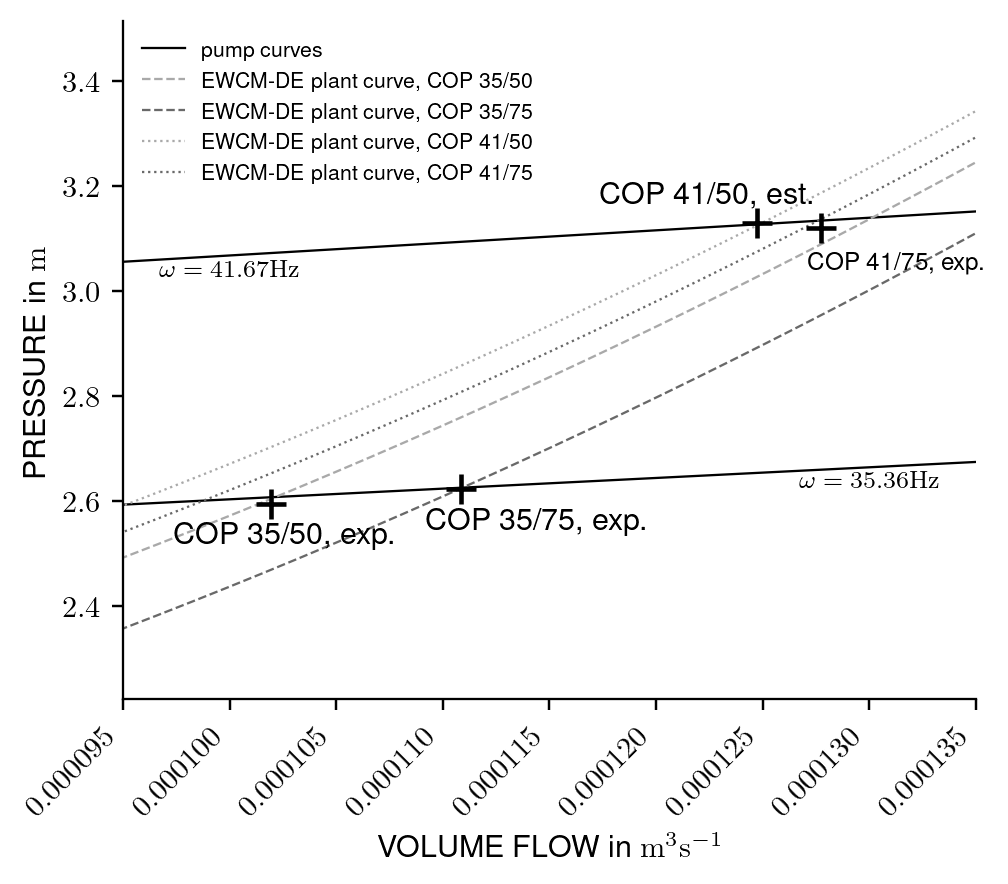

In [37]:
# plt.plot(q_list, pump_curve_1, c="r", linestyle="--", label="original pump curve 1")
# plt.plot(q_list, pump_curve_2, c="b", linestyle="--", label="original pump curve 2")

fig, ax = plt.subplots(figsize=(5, 4))

(l0,) = ax.plot(q_list, new_pump_curve_1, c="k", label="pump curves")
ax.plot(q_list, new_pump_curve_2, c="k", label="pump curve")

# plt.vlines(x1, 2.5, 3.6, color="lightgrey", linestyle="--", linewidth=0.5)
# plt.vlines(x2, 2.5, 3.6, color="grey", linestyle="--", linewidth=0.5)
# plt.vlines(x3, 2.5, 3.6, color="darkgrey", linestyle="--", linewidth=0.5)


# plt.hlines(
#     y1, q_list.min(), q_list.max(), color="lightgrey", linestyle="--", linewidth=0.5
# )
# plt.hlines(y2, q_list.min(), q_list.max(), color="grey", linestyle="--", linewidth=0.5)
# plt.hlines(
#     y3, q_list.min(), q_list.max(), color="darkgrey", linestyle="--", linewidth=0.5
# )


(l1,) = ax.plot(
    q_list,
    [
        (8 * 7.25 * 0.10367) / (np.pi**2 * 9.81 * 0.015**5) * q**2 + 1.61908
        # 1.619080192380957
        for q in q_list
    ],  # 1.1767
    c="dimgrey",
    linestyle="--",
    label="EWCM-DE plant curve, COP 35/75",
)

(l2,) = ax.plot(
    q_list,
    [
        (8 * 7.25 * 0.10367) / (np.pi**2 * 9.81 * 0.015**5) * q**2 + 1.61908 + 0.135
        # 1.619080192380957
        for q in q_list
    ],  # 1.1767
    c="darkgrey",
    linestyle="--",
    label="EWCM-DE plant curve, COP 35/50",
)


(l3,) = ax.plot(
    q_list,
    [
        (8 * 7.25 * 0.1035) / (np.pi**2 * 9.81 * 0.015**5) * q**2
        + 1.61908
        + 0.185
        + 0.05
        # 1.619080192380957
        for q in q_list
    ],  # 1.1767
    c="darkgrey",
    linestyle=":",
    label="EWCM-DE plant curve, COP 41/50",
)

(l4,) = ax.plot(
    q_list,
    [
        (8 * 7.25 * 0.1035) / (np.pi**2 * 9.81 * 0.015**5) * q**2 + 1.61908 + 0.185
        # 1.619080192380957
        for q in q_list
    ],  # 1.1767
    c="dimgrey",
    linestyle=":",
    label="EWCM-DE plant curve, COP 41/75",
)


ax.scatter(x1, y1, marker="+", c="k", linewidth=1.5, s=100, zorder=100)
ax.scatter(x2, y2, marker="+", c="k", linewidth=1.5, s=100, zorder=100)
ax.scatter(x3, y3, marker="+", c="k", linewidth=1.5, s=100, zorder=100)
ax.scatter(
    x3 - 0.000003, y3 + 0.01, marker="+", c="k", linewidth=1.5, s=100, zorder=100
)

ax.annotate(
    "COP 35/75, exp.",
    xy=(x1, y1),
    xycoords="data",
    xytext=(25, -15),
    textcoords="offset points",
    # arrowprops=dict(facecolor="black", width=0.1, headlength=0.001),
    horizontalalignment="center",
    verticalalignment="bottom",
)

ax.annotate(
    "COP 35/50, exp.",
    xy=(x2, y2),
    xycoords="data",
    xytext=(5, -15),
    textcoords="offset points",
    # arrowprops=dict(facecolor="black", width=0.1, headlength=0.001),
    horizontalalignment="center",
    verticalalignment="bottom",
)

ax.annotate(
    "COP 41/75, exp.",
    xy=(x3, y3),
    xycoords="data",
    xytext=(25, -15),
    textcoords="offset points",
    # arrowprops=dict(facecolor="black", width=0.1, headlength=0.001),
    horizontalalignment="center",
    verticalalignment="bottom",
    fontsize=8,
)

ax.annotate(
    "COP 41/50, est.",
    xy=(x3 - 0.000001, y3),
    xycoords="data",
    xytext=(-30, 6),
    textcoords="offset points",
    # arrowprops=dict(facecolor="black", width=0.1, headlength=0.001),
    horizontalalignment="center",
    verticalalignment="bottom",
)

ax.annotate(
    "$\omega=35.36\mathrm{Hz}$",
    xy=(0.00013, 2.6),
    xycoords="data",
    # xytext=(-25, 5),
    textcoords="offset points",
    # arrowprops=dict(facecolor="black", width=0.1, headlength=0.001),
    horizontalalignment="center",
    verticalalignment="bottom",
    fontsize=8,
    # backgroundcolor="1.0",
)

ax.annotate(
    "$\omega=41.67\mathrm{Hz}$",
    xy=(0.0001, 3),
    xycoords="data",
    # xytext=(-25, 5),
    textcoords="offset points",
    # arrowprops=dict(facecolor="black", width=0.1, headlength=0.001),
    horizontalalignment="center",
    verticalalignment="bottom",
    fontsize=8,
    # backgroundcolor="1.0",
)

ax.set_xlim((0.000095, 0.000135))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_ylim()
ax.legend(handles=[l0, l2, l1, l3, l4], fontsize=7)

ax.set_xlabel("VOLUME FLOW in $\mathrm{m}^3\mathrm{s}^{-1}$")
ax.set_ylabel("PRESSURE in $\mathrm{m}$")

# fig.savefig("fig_pump_curves.pdf", bbox_inches="tight")
fig.savefig("fig_pump_curves_COP.svg", bbox_inches="tight")
fig.savefig("fig_pump_curves_COP.png", bbox_inches="tight")

In [28]:
import sympy as sp

In [29]:
# Define symbols
a, b, c = sp.symbols("x y z")

# Define equations
eq1 = a * x1**2 + b * s_1 * x1 + c * s_1 - y1
eq2 = a * x2**2 + b * s_1 * x2 + c * s_1 - y2
eq3 = a * x3**2 + b * s_2 * x3 + c * s_2 - y3

solution = sp.solve([eq1, eq2, eq3], (a, b, c))

print(solution)

{x: 13205998.7008792, y: 7.37859226962694, z: 0.0687476841064746}


In [30]:
import numpy as np
from scipy.optimize import least_squares

c = k3  # fixed known value


def residuals(vars):
    a, b, c = vars
    a = k1  # fixed known value

    f1 = a * x1**2 + b * s_1 * x1 + c * s_1 - y1
    f2 = a * x2**2 + b * s_1 * x2 + c * s_1 - y2
    f3 = a * x3**2 + b * s_2 * x3 + c * s_2 - y3

    return [f1, f2, f3]


initial_guess = [1.0, 1.0, 1.0]

result = least_squares(residuals, initial_guess)

print("Solution:", result.x)
print("Residual norm:", np.linalg.norm(result.fun))

Solution: [ 1.         57.45648878  0.06786977]
Residual norm: 0.008008537243282803
